# ETF 动量 + 风险平价策略

In [1]:
import numpy as np

from core.database import create_session
from core.database.core import CORE_TABLE

2026-07-28 16:48:35 [SUCCESS] ts_api.py | <module>: 187行| Tushare Pro 初始化完成，共加载 5,871 只股票
2026-07-28 16:48:35 [ INFO  ] session.py | <module>: 10行| DolphinDB: 127.0.0.1:8848


In [2]:
session = create_session()

In [3]:
CODE_NAMES = [
    "518880.SH",  # 黄金
    "159980.SZ",  # 有色
    "159985.SZ",  # 豆粕
    "501018.SH",  # 原油
    "513400.SH",  # 道琼斯
    "513100.SH",  # 纳指
    "513500.SH",  # 标普500
    "513120.SH",  # 港股创新药
    "513070.SH",  # 港股消费
    "588000.SH",  # 科创50
    "159967.SZ",  # 创成长
    "512890.SH",  # 红利低波
    "513880.SH",  # 日经225
]
FACTOR_NAMES = [
    "open",
    "high",
    "low",
    "close",
    "pre_close",
    "adj_factor",
    "vol",
]
START_DATE = np.datetime64("2022-01-01", "D")
END_DATE = np.datetime64("2026-07-26", "D")
INITIAL_CASH = 100_000.0
MOMENTUM_WINDOW = 21
SELECT_COUNT = 4
RISK_WINDOW = 20
MAX_HISTORY_ROWS = 90
HISTORY_BUFFER_DAYS = 120
TARGET_VOLATILITY = 0.09
MAX_INVESTED_RATIO = 0.99

In [4]:
session.upload({
    "strategyStartDate": START_DATE,
    "strategyEndDate": END_DATE,
    "strategyInitialCash": INITIAL_CASH,
    "strategyCodeNames": np.asarray(CODE_NAMES, dtype=str),
    "strategyFactorNames": np.asarray(FACTOR_NAMES, dtype=str),
    "strategyMomentumWindow": MOMENTUM_WINDOW,
    "strategySelectCount": SELECT_COUNT,
    "strategyRiskWindow": RISK_WINDOW,
    "strategyMaxHistoryRows": MAX_HISTORY_ROWS,
    "strategyHistoryBufferDays": HISTORY_BUFFER_DAYS,
    "strategyTargetVolatility": TARGET_VOLATILITY,
    "strategyMaxInvestedRatio": MAX_INVESTED_RATIO,
    "strategyEngineName": "etf-engine-1",
    "strategySignalAnnualizationDays": 252,
    "strategyPerformanceAnnualizationDays": 250,
    "strategyRiskFreeRate": 0.04,
    "strategyOptimizerMaxIterations": 1_000,
    "strategyOptimizerTolerance": 1e-9,
    "strategySlippageRate": 0.00246,
    "strategyPricePrecision": 3,
    "strategyLotSize": 100,
    "strategyCommission": 0.00005,
    "strategyEnableMinimumTransactionFee": True,
    "strategyTax": 0.0,
    "strategyGroup": "stock",
    "strategyBacktestDataType": 4,
    "strategyMessageAsTable": True,
    "strategyMatchingMode": 3,
})


[397222240,
 397216320,
 426789152,
 292726912,
 238281984,
 514202144,
 421526112,
 336585856,
 340032704,
 506758272,
 506304224,
 342787424,
 286150544,
 506305696,
 503624640,
 441903776,
 371448768,
 514201888,
 378628160,
 407919872,
 500582144,
 513807680,
 422256768,
 347103424,
 364277360,
 378631744,
 387032896,
 345848128]

## 1. 从 CoreData 构造 Backtest 日频消息

In [5]:
session.run("""use backtest""")

In [6]:
session.run(f"""
strategyCodes = symbol(strategyCodeNames)
strategySymbols = symbol(
    strReplace(
        strReplace(string(strategyCodes), ".SZ", ".XSHE"),
        ".SH",
        ".XSHG"
    )
)

strategyMarketData = select
        time,
        code,
        double(open * adj_factor) as open,
        double(low * adj_factor) as low,
        double(high * adj_factor) as high,
        double(close * adj_factor) as close,
        long(round(vol * 100, 0)) as volume,
        double(
            iif(
                high > round(pre_close * 1.1, 3),
                high,
                round(pre_close * 1.1, 3)
            ) * adj_factor
        ) as upLimitPrice,
        double(
            iif(
                low < round(pre_close * 0.9, 3),
                low,
                round(pre_close * 0.9, 3)
            ) * adj_factor
        ) as downLimitPrice,
        double(pre_close * adj_factor) as prevClosePrice
    from (
        select first(value) as value
        from {CORE_TABLE}
        where
            time >= temporalAdd(
                strategyStartDate,
                -strategyHistoryBufferDays,
                "d"
            ),
            time <= strategyEndDate,
            code in strategyCodes,
            factor in symbol(strategyFactorNames)
        pivot by time, code, factor
    )
    where
        !isNull(open),
        !isNull(low),
        !isNull(high),
        !isNull(close),
        !isNull(pre_close),
        !isNull(adj_factor),
        !isNull(vol),
        close > 0,
        vol >= 0
    order by time, code

strategyMessage = backtest::build_backtest_message(
    select *
    from strategyMarketData
    where
        date(time) >= strategyStartDate,
        date(time) <= strategyEndDate
)
""")


## 2. 定义策略并运行回测

In [7]:
session.run("""
def etfMomentumScore(history, targetCode, window, annualTradingDays) {
    rows = select
        time,
        close
    from history
    where
        code == targetCode,
        !isNull(close),
        close > 0
    order by time desc
    if (rows.rows() < window) return double(NULL)
    rows = rows[0:window]

    prices = double(reverse(rows.close))
    logReturns =
        log(prices[1:window]) -
        log(prices[0:(window - 1)])
    volatility = stdp(logReturns) * sqrt(annualTradingDays)

    x = double(0..(window - 1))
    // numpy.polyfit 的 w 作用于残差，正规方程中的权重为 w²。
    regressionWeights = square(1.0 + x / (window - 1))
    y = log(prices)
    xMean = sum(regressionWeights * x) / sum(regressionWeights)
    yMean = sum(regressionWeights * y) / sum(regressionWeights)
    denominator = sum(
        regressionWeights * (x - xMean) * (x - xMean)
    )
    if (denominator <= 0) return double(NULL)

    slope = sum(
        regressionWeights *
        (x - xMean) *
        (y - yMean)
    ) / denominator
    annualReturn = exp(slope * annualTradingDays) - 1.0
    return annualReturn / (volatility + 1e-6)
}

def etfRiskParityCovariance(history, codes, window, maxHistoryRows, annualTradingDays) {
    priceHistory = select
        time,
        code,
        close
    from history
    where
        code in codes,
        !isNull(close),
        close > 0
    if (priceHistory.rows() == 0) {
        return (matrix(DOUBLE, size(codes), size(codes)), 0)
    }

    historyWide = select first(close) as close
    from priceHistory
    pivot by time, code
    historyWide = select *
    from historyWide
    order by time desc
    historyWide = historyWide[0:min(maxHistoryRows, historyWide.rows())]

    availableCodes = columnNames(historyWide)[1:]
    missingCodes = string(codes)[
        !(string(codes) in availableCodes)
    ]
    if (size(missingCodes) > 0) {
        return (matrix(DOUBLE, size(codes), size(codes)), 0)
    }

    priceColumns = historyWide[codes]
    validRows = take(true, historyWide.rows())
    for (index in 0..(size(codes) - 1)) {
        validRows = validRows && !isNull(priceColumns[index])
    }
    validIndices = (0..(historyWide.rows() - 1))[validRows]
    observationCount = min(size(validIndices), window)
    if (observationCount < window) {
        return (
            matrix(DOUBLE, size(codes), size(codes)),
            observationCount
        )
    }
    validIndices = reverse(validIndices[0:observationCount])

    count = size(codes)
    returns = array(ANY, 0)
    for (index in 0..(count - 1)) {
        prices = double(priceColumns[index][validIndices])
        returns.append!(
            log(prices[1:window]) -
            log(prices[0:(window - 1)])
        )
    }

    covariance = matrix(DOUBLE, count, count)
    for (leftIndex in 0..(count - 1)) {
        for (rightIndex in leftIndex..(count - 1)) {
            value = annualTradingDays * covar(
                returns[leftIndex],
                returns[rightIndex]
            )
            covariance[leftIndex, rightIndex] = value
            covariance[rightIndex, leftIndex] = value
        }
    }
    for (index in 0..(count - 1)) {
        covariance[index, index] += 1e-6
    }
    return (covariance, observationCount)
}

def etfRiskParityObjective(weights, covariance) {
    count = size(weights)
    covarianceTimesWeights = take(0.0, count)
    for (index in 0..(count - 1)) {
        covarianceTimesWeights[index] = sum(
            flatten(covariance[index,]) * weights
        )
    }
    portfolioVolatility = sqrt(
        sum(weights * covarianceTimesWeights)
    )
    if (portfolioVolatility <= 0) return double("inf")
    riskContributions =
        weights * covarianceTimesWeights / portfolioVolatility
    targetContribution = portfolioVolatility / count
    return sum(square(riskContributions - targetContribution))
}

def etfWeightSumConstraint(weights) {
    return sum(weights) - 1.0
}

def etfWeightSumJacobian(weights) {
    return take(1.0, size(weights))
}

def etfNonnegativeConstraint(weights) {
    return weights
}

def etfNonnegativeJacobian(weights) {
    count = size(weights)
    result = matrix(DOUBLE, count, count, 0)
    for (index in 0..(count - 1)) result[index, index] = 1.0
    return result
}

def etfRiskParityWeights(covariance, maxIterations, tolerance) {
    count = rows(covariance)
    if (count == 0 || cols(covariance) != count) {
        throw "协方差矩阵必须是非空方阵"
    }

    equalityConstraint = dict(STRING, ANY)
    equalityConstraint[`type] = `eq
    equalityConstraint[`fun] = etfWeightSumConstraint
    equalityConstraint[`jac] = etfWeightSumJacobian
    nonnegativeConstraint = dict(STRING, ANY)
    nonnegativeConstraint[`type] = `ineq
    nonnegativeConstraint[`fun] = etfNonnegativeConstraint
    nonnegativeConstraint[`jac] = etfNonnegativeJacobian
    bounds = matrix(take(0.0, count), take(1.0, count))
    optimization = fminSLSQP(
        etfRiskParityObjective{, covariance},
        take(1.0 / count, count),
        constraints=[equalityConstraint, nonnegativeConstraint],
        bounds=bounds,
        ftol=tolerance,
        maxIter=maxIterations
    )
    if (optimization[`mode] != 0) {
        throw "SLSQP 风险平价优化失败"
    }
    return optimization[`xopt]
}

def etfInitialize(mutable context) {
    context["rebalanceCount"] = 0
    context["rebalanceDateLog"] = array(DATE, 0)
    context["selectionLog"] = array(STRING, 0)
    context["weightLog"] = array(STRING, 0)
    context["portfolioVolatilityLog"] = array(DOUBLE, 0)
    context["targetExposureLog"] = array(DOUBLE, 0)
}

def etfOnBar(parameters, mutable context, msg, indicator) {
    strategyCodes = parameters["codes"]
    strategySymbols = parameters["symbols"]
    strategyMomentumWindow = parameters["momentumWindow"]
    strategySelectCount = parameters["selectCount"]
    strategyRiskWindow = parameters["riskWindow"]
    strategyMaxHistoryRows = parameters["maxHistoryRows"]
    strategyTargetVolatility = parameters["targetVolatility"]
    strategyMaxInvestedRatio = parameters["maxInvestedRatio"]
    strategySlippageRate = parameters["slippageRate"]
    strategyPricePrecision = parameters["pricePrecision"]
    strategyLotSize = parameters["lotSize"]
    strategySignalAnnualizationDays = parameters["signalAnnualizationDays"]
    strategyOptimizerMaxIterations = parameters["optimizerMaxIterations"]
    strategyOptimizerTolerance = parameters["optimizerTolerance"]
    if (msg.rows() == 0) return
    currentDate = date(msg.tradeTime[0])
    slippage = strategySlippageRate / 2.0
    pricePrecision = strategyPricePrecision
    messageSymbols = symbol(string(msg.symbol))
    messageVolumes = long(msg.volume)
    calendarData = context["coreBacktestUnfilteredFactorData"]
    nextTradeDate = exec min(date(time))
    from calendarData
    where date(time) > currentDate
    if (
        !isNull(nextTradeDate) &&
        weekOfYear(nextTradeDate) == weekOfYear(currentDate)
    ) return

    // 只读取当前消息日期之前的数据，禁止使用当日收盘价。
    history = backtest::getHistoryData(context, msg, false)
    if (history.rows() == 0) return

    scores = take(double(NULL), size(strategyCodes))
    for (index in 0..(size(strategyCodes) - 1)) {
        scores[index] = etfMomentumScore(
            history,
            strategyCodes[index],
            strategyMomentumWindow,
            strategySignalAnnualizationDays
        )
    }
    scoreTable = table(strategyCodes as code, scores as score)
    selected = select *
    from scoreTable
    where !isNull(score)
    order by score desc
    if (selected.rows() == 0) return
    selected = selected[0:min(strategySelectCount, selected.rows())]

    selectedCodes = selected.code
    selectedSymbols = symbol(
        strReplace(
            strReplace(string(selectedCodes), ".SZ", ".XSHE"),
            ".SH",
            ".XSHG"
        )
    )
    covarianceResult = etfRiskParityCovariance(
        history,
        selectedCodes,
        strategyRiskWindow,
        strategyMaxHistoryRows,
        strategySignalAnnualizationDays
    )
    if (covarianceResult[1] < strategyRiskWindow) return

    covariance = covarianceResult[0]
    weights = etfRiskParityWeights(
        covariance,
        strategyOptimizerMaxIterations,
        strategyOptimizerTolerance
    )
    marginalRisk = take(0.0, size(weights))
    for (index in 0..(size(weights) - 1)) {
        marginalRisk[index] = sum(
            flatten(covariance[index,]) * weights
        )
    }
    portfolioVolatility = sqrt(sum(weights * marginalRisk))
    targetExposure = 1.0
    if (portfolioVolatility > strategyTargetVolatility) {
        targetExposure =
            strategyTargetVolatility / portfolioVolatility
        weights *= targetExposure
    }

    // 聚宽在 09:30 回调中按当日开盘价估值可交易持仓；停牌持仓
    // 没有当日行情，继续使用最近一个收盘价估值。
    totalEquity = Backtest::getAvailableCash(context.engine)
    pausedValue = 0.0
    for (index in 0..(size(strategySymbols) - 1)) {
        currentSymbol = strategySymbols[index]
        position = Backtest::getPosition(
            context.engine,
            currentSymbol
        )
        currentPosition = long(
            nullFill(position.longPosition.sum(), 0)
        )
        messageIndex = find(messageSymbols, currentSymbol)
        paused = messageIndex < 0
        if (!paused) paused = messageVolumes[messageIndex] <= 0
        if (currentPosition > 0 && !paused) {
            totalEquity += currentPosition * msg.open[messageIndex]
        }
        if (currentPosition > 0 && paused) {
            lastPrice = select top 1 close
            from history
            where code == strategyCodes[index]
            order by time desc
            if (lastPrice.rows() > 0) {
                positionValue = currentPosition * lastPrice.close[0]
                pausedValue += positionValue
                totalEquity += positionValue
            }
        }
    }
    if (isNull(totalEquity) || totalEquity <= 0) return

    allocatableEquity = strategyMaxInvestedRatio * (totalEquity - pausedValue)
    if (allocatableEquity <= 0) return
    targetPositions = take(long(0), size(selectedSymbols))
    executionPrices = take(double(NULL), size(selectedSymbols))
    for (index in 0..(size(selectedSymbols) - 1)) {
        currentSymbol = selectedSymbols[index]
        messageIndex = find(messageSymbols, currentSymbol)
        position = Backtest::getPosition(
            context.engine,
            currentSymbol
        )
        currentPosition = long(
            nullFill(position.longPosition.sum(), 0)
        )
        paused = messageIndex < 0
        if (!paused) paused = messageVolumes[messageIndex] <= 0
        if (paused) {
            targetPositions[index] = currentPosition
        } else {
            executionPrices[index] = msg.open[messageIndex]
            targetValue = allocatableEquity * weights[index]
            positionDifference =
                targetValue / executionPrices[index] - currentPosition
            positionAdjustment = long(
                floor(abs(positionDifference) / strategyLotSize) * strategyLotSize
            )
            targetPositions[index] = iif(
                positionDifference < 0,
                currentPosition - positionAdjustment,
                currentPosition + positionAdjustment
            )
        }
    }

    // 先卖出被剔除或超配的基金。
    for (index in 0..(size(strategySymbols) - 1)) {
        currentSymbol = strategySymbols[index]
        messageIndex = find(messageSymbols, currentSymbol)
        if (
            messageIndex < 0 ||
            messageVolumes[messageIndex] <= 0
        ) continue

        position = Backtest::getPosition(
            context.engine,
            currentSymbol
        )
        currentPosition = long(
            nullFill(position.longPosition.sum(), 0)
        )
        selectedIndex = find(selectedSymbols, currentSymbol)
        targetPosition = iif(
            selectedIndex < 0,
            long(0),
            targetPositions[selectedIndex]
        )
        if (currentPosition > targetPosition) {
            Backtest::submitOrder(
                context.engine,
                (
                    currentSymbol,
                    context.tradeTime,
                    5,
                    round(
                        msg.open[messageIndex] * (1.0 - slippage),
                        pricePrecision
                    ),
                    currentPosition - targetPosition,
                    3
                ),
                "etf-risk-parity-sell"
            )
        }
    }

    // 再买入低配基金。
    for (index in 0..(size(selectedSymbols) - 1)) {
        currentSymbol = selectedSymbols[index]
        messageIndex = find(messageSymbols, currentSymbol)
        if (
            messageIndex < 0 ||
            messageVolumes[messageIndex] <= 0
        ) continue

        position = Backtest::getPosition(
            context.engine,
            currentSymbol
        )
        currentPosition = long(
            nullFill(position.longPosition.sum(), 0)
        )
        targetPosition = targetPositions[index]
        if (currentPosition <= targetPosition - strategyLotSize) {
            Backtest::submitOrder(
                context.engine,
                (
                    currentSymbol,
                    context.tradeTime,
                    5,
                    round(
                        executionPrices[index] * (1.0 + slippage),
                        pricePrecision
                    ),
                    targetPosition - currentPosition,
                    1
                ),
                "etf-risk-parity-buy"
            )
        }
    }

    context["rebalanceCount"] += 1
    context["rebalanceDateLog"].append!(currentDate)
    selectionText = concat(string(selectedCodes), ",")
    weightText = concat(string(round(weights, 6)), ",")
    context["selectionLog"].append!(selectionText)
    context["weightLog"].append!(weightText)
    context["portfolioVolatilityLog"].append!(portfolioVolatility)
    context["targetExposureLog"].append!(targetExposure)
}
""")

In [8]:
session.run("""
strategyConfig = dict(STRING, ANY)
strategyConfig["startDate"] = strategyStartDate
strategyConfig["endDate"] = strategyEndDate
strategyConfig["strategyGroup"] = strategyGroup
strategyConfig["cash"] = double(strategyInitialCash)
strategyConfig["commission"] = double(strategyCommission)
strategyConfig["enableMinimumPerTransactionFee"] = strategyEnableMinimumTransactionFee
strategyConfig["tax"] = double(strategyTax)
strategyConfig["dataType"] = int(strategyBacktestDataType)
strategyConfig["msgAsTable"] = strategyMessageAsTable
strategyConfig["matchingMode"] = int(strategyMatchingMode)

strategyConfig
""")

{'cash': 100000.0,
 'msgAsTable': True,
 'enableMinimumPerTransactionFee': True,
 'dataType': 4,
 'tax': 0.0,
 'matchingMode': 3,
 'commission': 5e-05,
 'strategyGroup': 'stock',
 'endDate': np.datetime64('2026-07-26'),
 'startDate': np.datetime64('2022-01-01')}

In [9]:
session.run("""
strategyParameters = dict(STRING, ANY)
strategyParameters["codes"] = strategyCodes
strategyParameters["symbols"] = strategySymbols
strategyParameters["momentumWindow"] = strategyMomentumWindow
strategyParameters["selectCount"] = strategySelectCount
strategyParameters["riskWindow"] = strategyRiskWindow
strategyParameters["maxHistoryRows"] = strategyMaxHistoryRows
strategyParameters["targetVolatility"] = strategyTargetVolatility
strategyParameters["maxInvestedRatio"] = strategyMaxInvestedRatio
strategyParameters["slippageRate"] = strategySlippageRate
strategyParameters["pricePrecision"] = strategyPricePrecision
strategyParameters["lotSize"] = strategyLotSize
strategyParameters["signalAnnualizationDays"] = strategySignalAnnualizationDays
strategyParameters["optimizerMaxIterations"] = strategyOptimizerMaxIterations
strategyParameters["optimizerTolerance"] = strategyOptimizerTolerance

strategyParameters
""")

{'optimizerTolerance': 1e-09,
 'optimizerMaxIterations': 1000,
 'codes': array(['518880.SH', '159980.SZ', '159985.SZ', '501018.SH', '513400.SH',
        '513100.SH', '513500.SH', '513120.SH', '513070.SH', '588000.SH',
        '159967.SZ', '512890.SH', '513880.SH'], dtype=object),
 'signalAnnualizationDays': 252,
 'riskWindow': 20,
 'symbols': array(['518880.XSHG', '159980.XSHE', '159985.XSHE', '501018.XSHG',
        '513400.XSHG', '513100.XSHG', '513500.XSHG', '513120.XSHG',
        '513070.XSHG', '588000.XSHG', '159967.XSHE', '512890.XSHG',
        '513880.XSHG'], dtype=object),
 'maxHistoryRows': 90,
 'targetVolatility': 0.09,
 'maxInvestedRatio': 0.99,
 'momentumWindow': 21,
 'selectCount': 4,
 'lotSize': 100,
 'slippageRate': 0.00246,
 'pricePrecision': 3}

In [10]:
session.run("""
strategyEngine = backtest::run_backtest(
    strategyEngineName,
    strategyConfig,
    strategyMessage,
    strategyMarketData,
    strategyMarketData,
    etfInitialize,
    NULL,
    etfOnBar{strategyParameters},
    NULL,
    NULL,
    NULL,
    NULL,
    NULL
)

backtest::standardize_return_summary(
    Backtest::getReturnSummary(strategyEngine),
    Backtest::getDailyTotalPortfolios(strategyEngine),
    strategyPerformanceAnnualizationDays,
    strategyRiskFreeRate
)
""")

,totalReturn,annualReturn,annualVolatility,annualSkew,annualKur,sharpeRatio,maxDrawdown,drawdownRatio,beta,alpha,annualExcessReturn,benchmarkReturn,turnoverRate,dailyWinningRate
0,0.99032,0.168832,0.111768,-0.451575,9.932382,1.152678,0.085144,1.982915,0.0,0.0,0.0,0.0,0.06013,0.539091


<Axes: xlabel='tradeDate'>

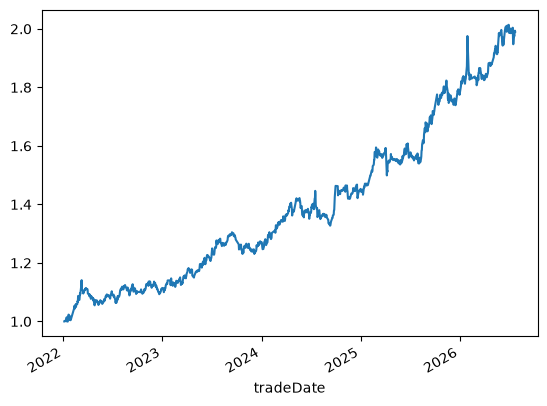

In [11]:
session.run("""
            select tradeDate,
                   netValue
            from Backtest::getDailyTotalPortfolios(strategyEngine)
            order by tradeDate
            """).set_index("tradeDate")["netValue"].plot()

## 3. 清理回测引擎

In [12]:
session.run("Backtest::dropBacktestEngine(strategyEngine)")
session.close()